In [1]:
import pynucastro as pyna

In [2]:
rl = pyna.ReacLibLibrary()

In [3]:
n14pg = rl.get_rate_by_name("n14(p,g)o15")
o15betap = rl.get_rate_by_name("o15(,)n15")
o14betap = rl.get_rate_by_name("o14(,)n14")

In [4]:
import matplotlib.pyplot as plt
import numpy as np

In [44]:
Ts = np.logspace(7, 8.5, 50)

In [45]:
rho = 100
comp = pyna.Composition(["p", "he4", "c12", "n14", "n15", "o15", "o16"],
                        init="solar")

In [46]:
Yp = comp.get_molar()[pyna.Nucleus("p")]

In [47]:
lam_n14pg = [n14pg.eval(T, rho=rho, comp=comp) for T in Ts]
lam_o15betap = [o15betap.eval(T, rho=rho, comp=comp) / (rho * Yp) for T in Ts]
lam_o14betap = [o14betap.eval(T, rho=rho, comp=comp) / (rho * Yp) for T in Ts]

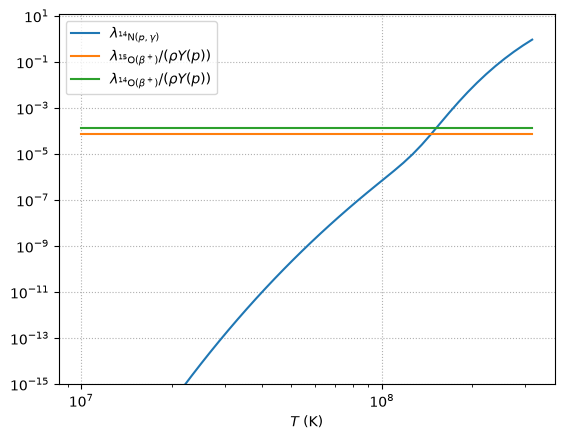

In [53]:
fig, ax = plt.subplots()
ax.loglog(Ts, lam_n14pg, label=r"$\lambda_{{}^{14}\mathrm{N}(p,\gamma)}$")
ax.loglog(Ts, lam_o15betap, label=r"$\lambda_{{}^{15}\mathrm{O}(\beta^+)} / (\rho Y(p))$")
ax.loglog(Ts, lam_o14betap, label=r"$\lambda_{{}^{14}\mathrm{O}(\beta^+)} / (\rho Y(p))$")

ax.grid(ls=":")
ax.set_ylim(1.e-15,)
ax.set_xlabel(r"$T$ (K)")
ax.legend()

In [54]:
n14pg_betalim = pyna.rates.BetaLimitedRate(n14pg,
                                           [o15betap, o14betap],
                                           limiter_nucleus="p")

In [55]:
lam_n14pg_betalim = [n14pg_betalim.eval(T, rho=rho, comp=comp) for T in Ts]

In [56]:
ax.loglog(Ts, lam_n14pg_betalim,
          label=r"$\lambda_{{}^{14}\mathrm{N}(p,\gamma)}\, \beta \rm{-limited}$")
ax.legend()

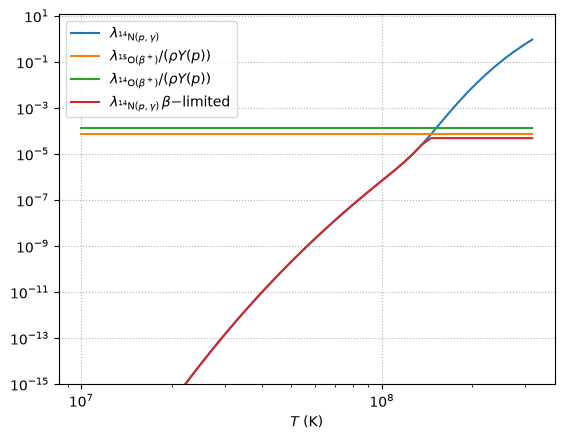

In [57]:
fig